In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/1pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.154015
2017-11-25 01:10:00,-1.293020,-1.197142
2017-11-25 01:20:00,-1.333732,-1.360749
2017-11-25 01:30:00,-1.353240,-1.342078
2017-11-25 01:40:00,-1.345607,-1.355636


In [4]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/1pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.182522
2017-11-25 01:10:00,-1.293020,-1.216506
2017-11-25 01:20:00,-1.333732,-1.324758
2017-11-25 01:30:00,-1.353240,-1.355393
2017-11-25 01:40:00,-1.345607,-1.359049


In [5]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/1pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.184755
2017-11-25 01:10:00,-1.293020,-1.217403
2017-11-25 01:20:00,-1.333732,-1.332091
2017-11-25 01:30:00,-1.353240,-1.358106
2017-11-25 01:40:00,-1.345607,-1.371677


In [6]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.197553
2017-11-25 01:10:00,-1.293020,-1.242730
2017-11-25 01:20:00,-1.333732,-1.339002
2017-11-25 01:30:00,-1.353240,-1.385698
2017-11-25 01:40:00,-1.345607,-1.403491


In [7]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.181835
2017-11-25 01:10:00,-1.293020,-1.250166
2017-11-25 01:20:00,-1.333732,-1.331410
2017-11-25 01:30:00,-1.353240,-1.404249
2017-11-25 01:40:00,-1.345607,-1.427199


In [8]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/1paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 5347 - 5190
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.171613
2017-11-25 01:10:00,-1.293020,-1.217051
2017-11-25 01:20:00,-1.333732,-1.340592
2017-11-25 01:30:00,-1.353240,-1.356238
2017-11-25 01:40:00,-1.345607,-1.373040


## MLP ##

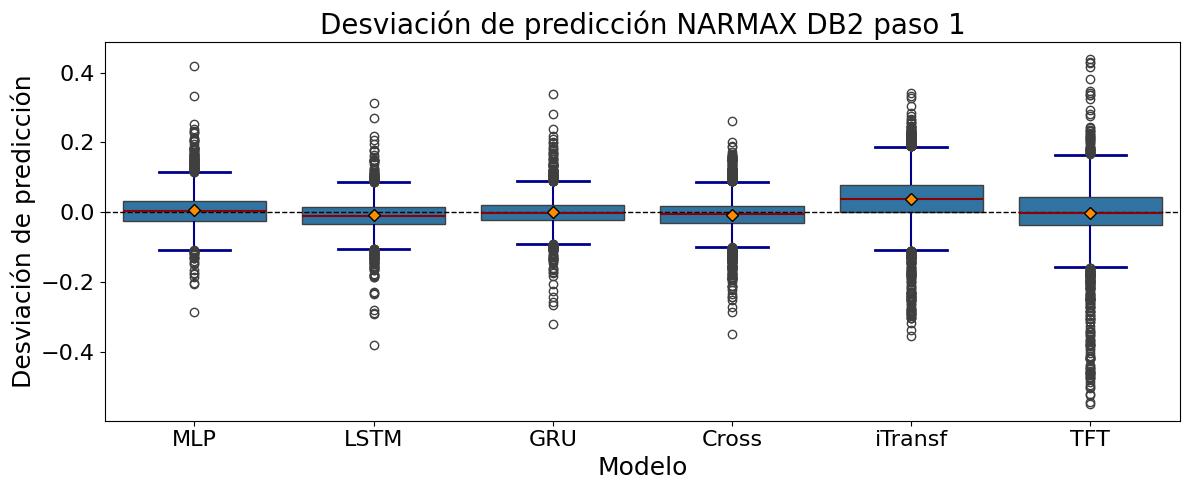

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARMAX DB2 paso 1', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda

# Ajustar la presentación
plt.tight_layout()
plt.show()


# Graficos Q-Q

In [10]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:00:00,-0.031289,-0.002781,-0.000549,0.012249,-0.003468,-0.013691
2017-11-25 01:10:00,-0.095878,-0.076515,-0.075618,-0.050290,-0.042855,-0.075970
2017-11-25 01:20:00,0.027017,-0.008974,-0.001642,0.005270,-0.002323,0.006859
2017-11-25 01:30:00,-0.011162,0.002153,0.004866,0.032458,0.051009,0.002998
2017-11-25 01:40:00,0.010030,0.013443,0.026070,0.057885,0.081593,0.027433


In [11]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [12]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-12-05 22:30:00,-0.064889,-0.044094,-0.035954,-0.019226,-0.005494,0.004564
2017-11-30 06:10:00,0.061115,0.034354,0.048027,0.022072,0.101039,0.034326
2017-12-15 23:50:00,-0.068638,-0.017627,-0.022977,-0.000616,0.047021,-0.005426
2017-12-24 08:50:00,0.036998,-0.061263,-0.028670,-0.017015,-0.100660,-0.146250
2017-12-22 19:50:00,0.076301,0.042081,0.056918,0.047583,0.122824,0.116788


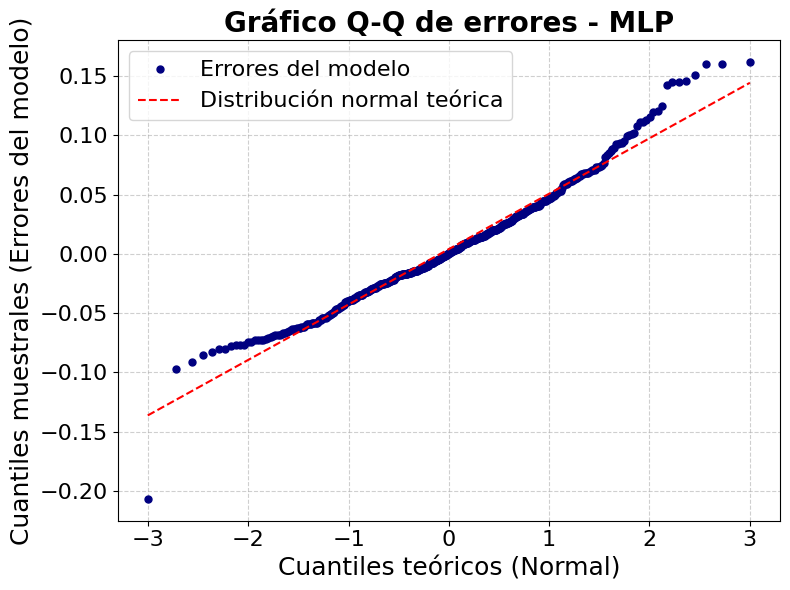

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


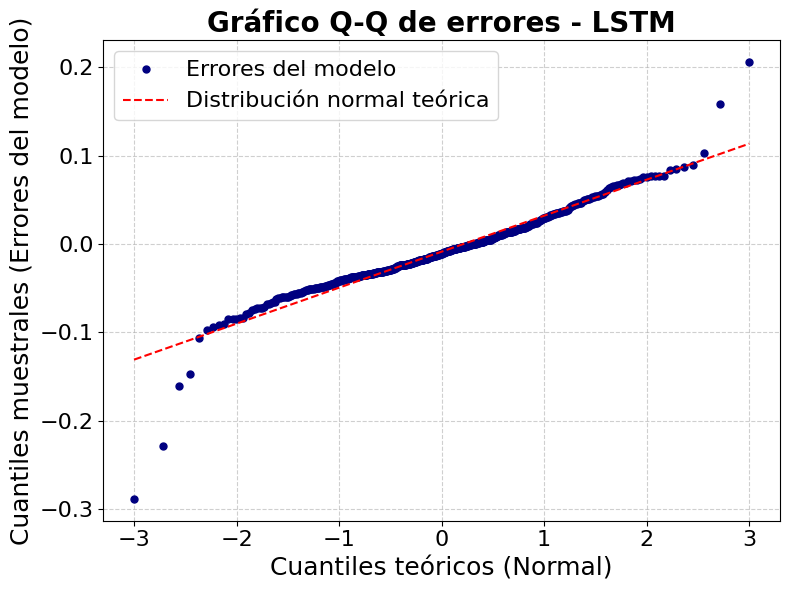

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


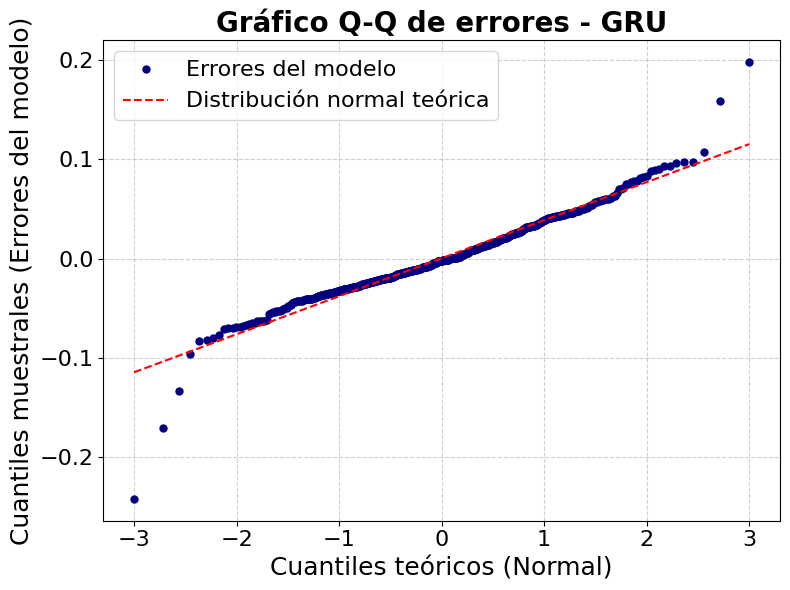

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


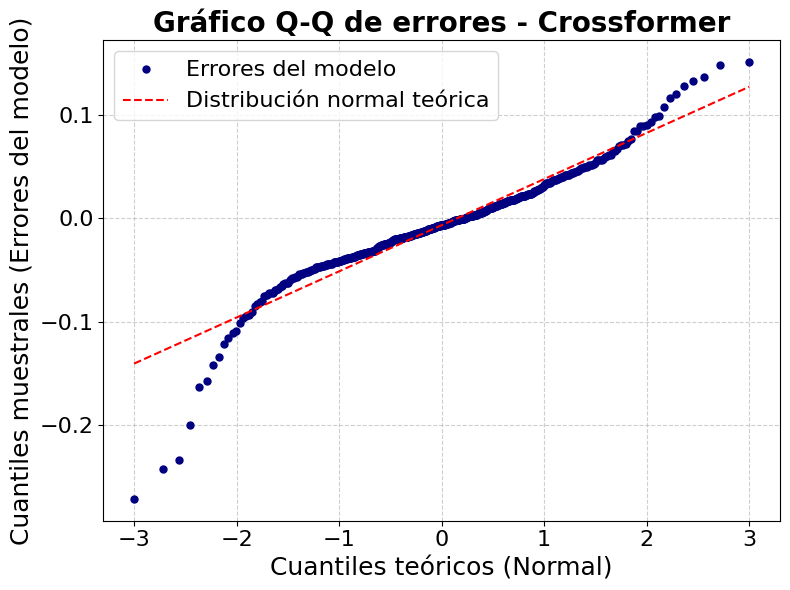

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


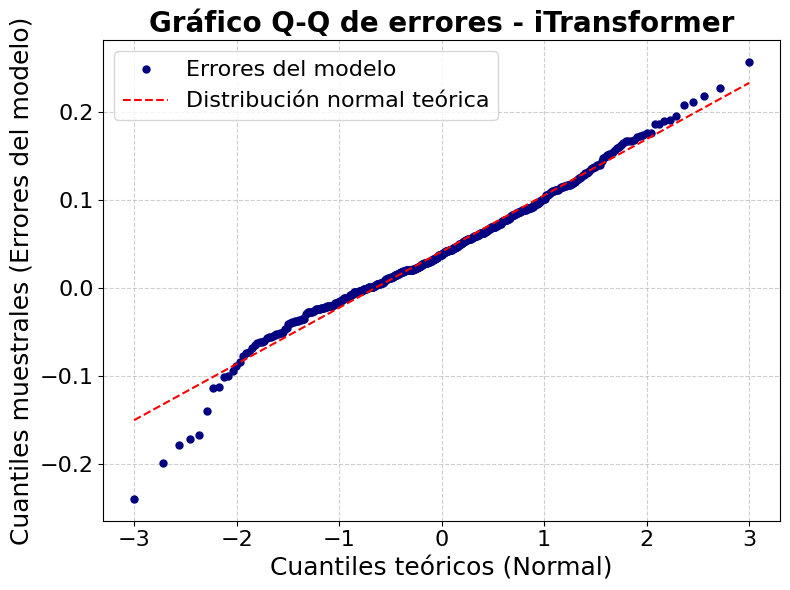

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


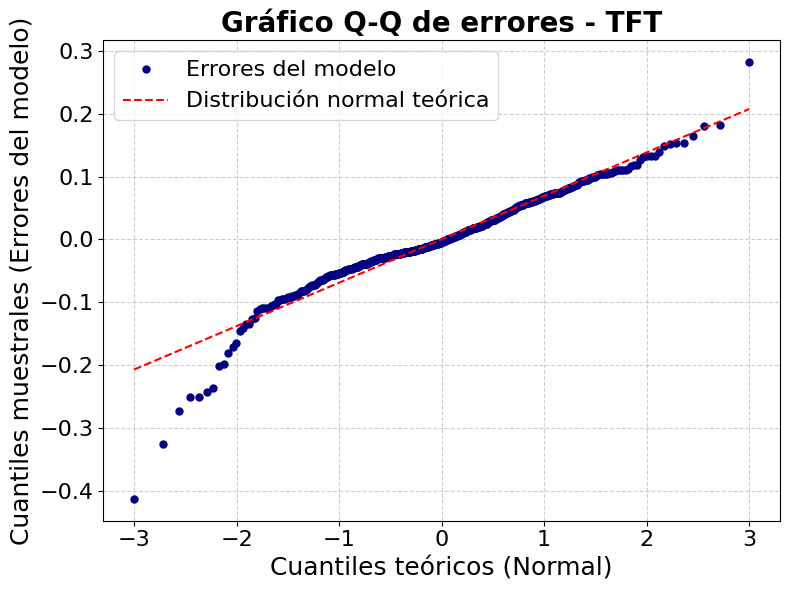

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

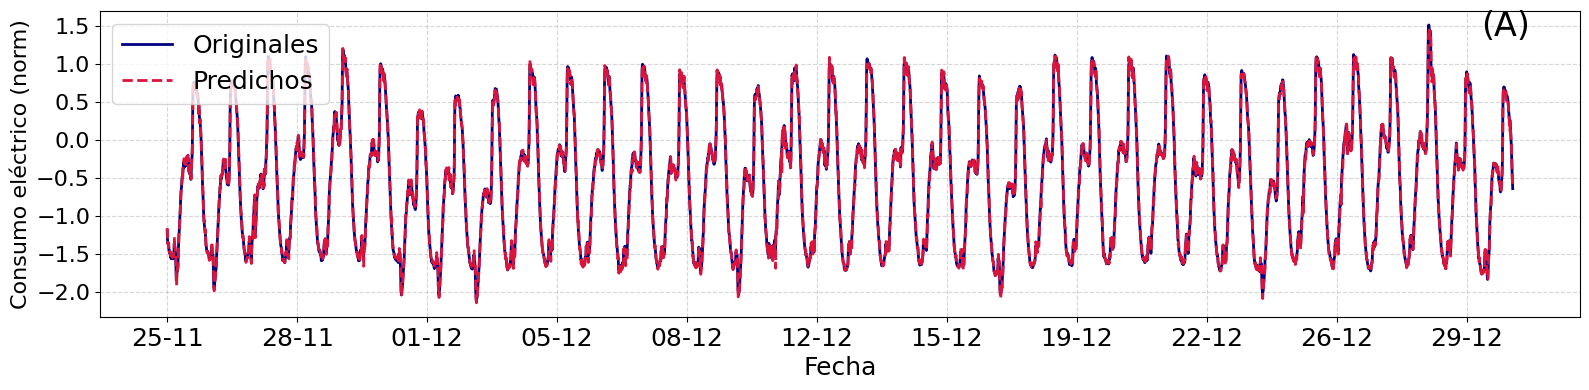

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(16, 4))

df = datosMLP
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()


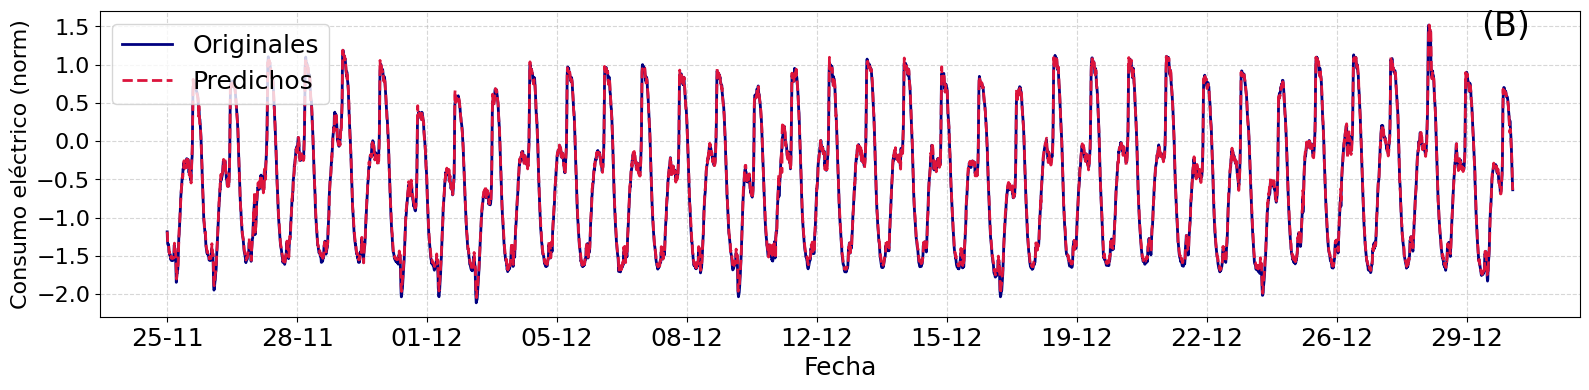

In [20]:

plt.figure(figsize=(16, 4))

df = datosLSTM
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

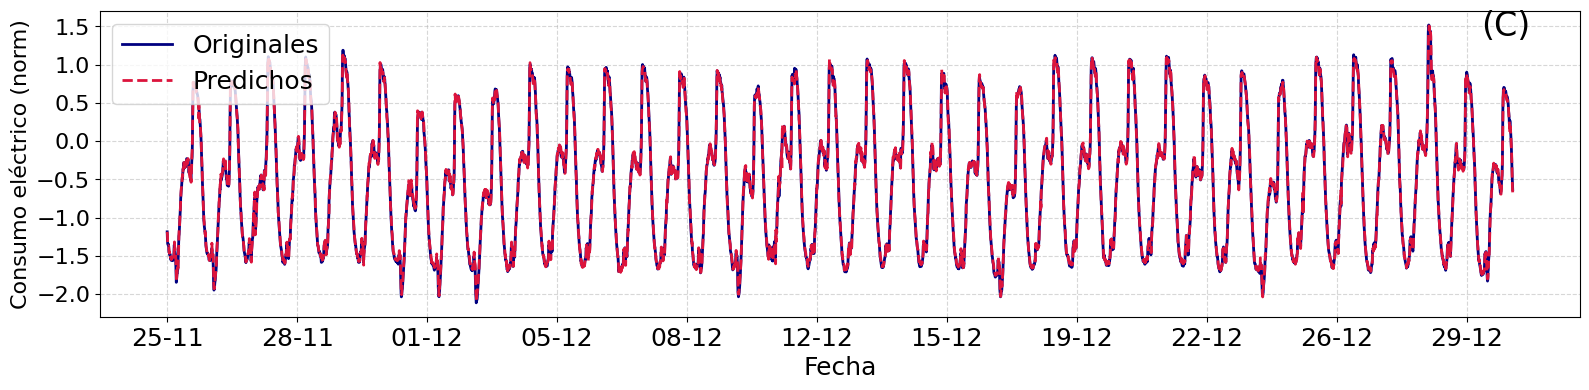

In [21]:

plt.figure(figsize=(16, 4))

df = datosGRU
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

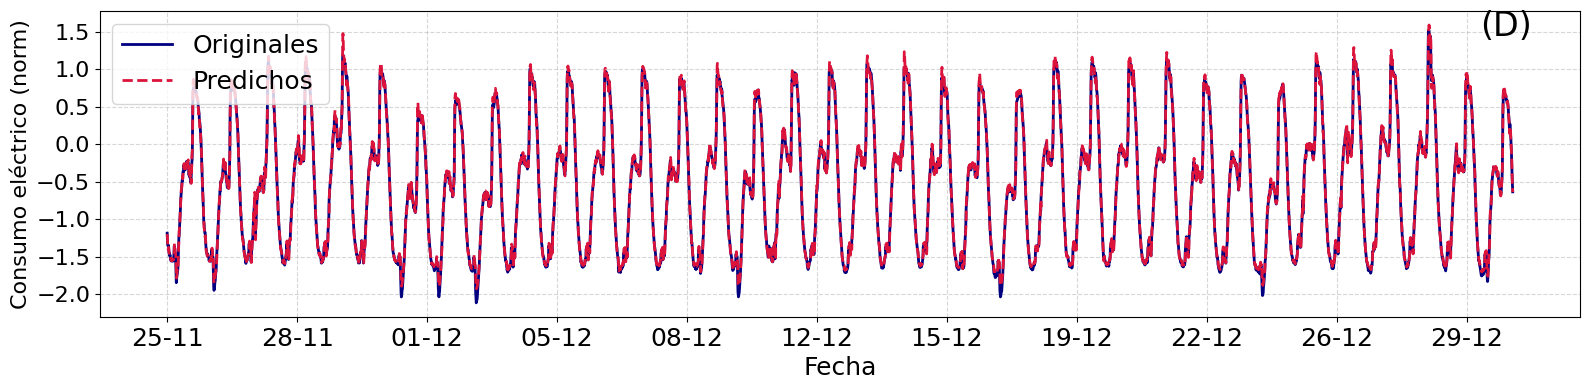

In [22]:

plt.figure(figsize=(16, 4))

df = datosCross
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

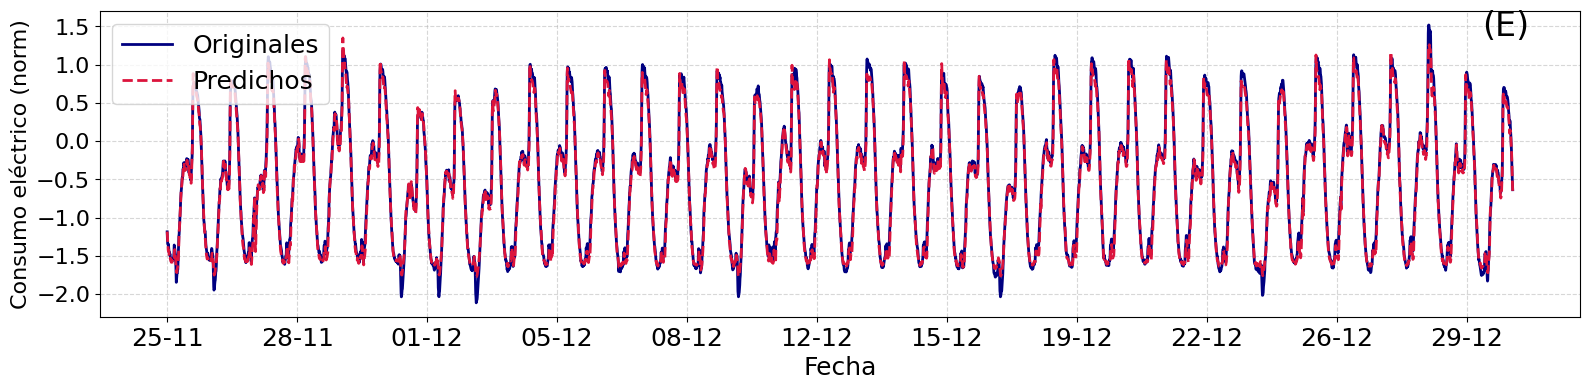

In [23]:

plt.figure(figsize=(16, 4))

df = datosI
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

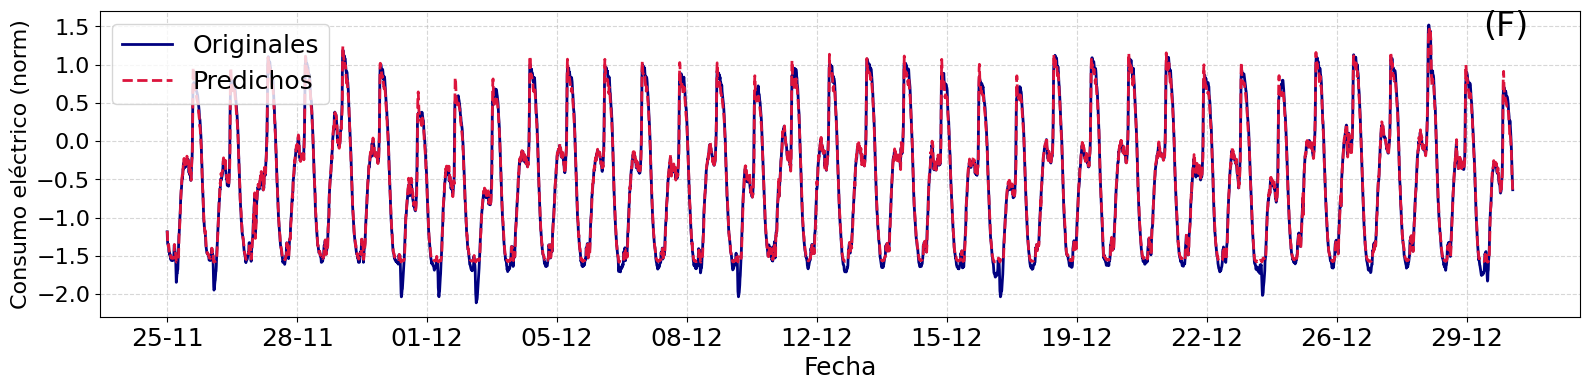

In [24]:

plt.figure(figsize=(16, 4))

df = datosTFT
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

# Métricas

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [26]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0021844329567018332
RMSE: 0.046737917761725686
MAE: 0.03493187850954053
SMAPE: 0.11611910198290255
IA: 0.9758663071288873


In [27]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0018011746523961022
RMSE: 0.042440248024677024
MAE: 0.03167746387641398
SMAPE: 0.09920898597506685
IA: 0.9779451188130355


In [28]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.001563560509474163
RMSE: 0.03954188297835806
MAE: 0.028923095510291322
SMAPE: 0.09755229622761787
IA: 0.9799521021876363


In [29]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.002172818503700077
RMSE: 0.04661350130273499
MAE: 0.03323425685005871
SMAPE: 0.1090534892278949
IA: 0.9770555359144473


In [30]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.006354776439054768
RMSE: 0.07971685166296251
MAE: 0.060354372895672075
SMAPE: 0.15281699052478986
IA: 0.957800566450121


In [31]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0065957111575134396
RMSE: 0.08121398375596064
MAE: 0.0549442312084458
SMAPE: 0.1399700072417183
IA: 0.9613653851134716


# Pruebas de significación

In [32]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [33]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 6.663116285461082e-101
LSTM: 4.28674526713057e-100
GRU: 1.726223437058407e-100
Cross: 4.3876670116345207e-94
iTransf: 1.1481600251676849e-93
TFT: 5.066406324789479e-88


In [34]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

7.0993460184507315e-130


In [35]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00000,0.00000,0.00000
1,MLP vs GRU,0.00369,0.05537,0.01477
2,MLP vs Crossformer,0.00001,0.00008,0.00004
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.69431,1.00000,1.00000
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.00020,0.00299,0.00100
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00006,0.00003
9,GRU vs Crossformer,0.00014,0.00211,0.00084
